# ECG Arrhythmia Classification with 1D-CNN

Trains a **1D Convolutional Neural Network** to classify ECG beats into arrhythmia types using the **MIT-BIH Arrhythmia Database**. Covers data ingestion, preprocessing, model training, evaluation, and Grad-CAM explainability.

| Class | Label | Description |
|-------|-------|-------------|
| N | Normal | Regular SA-node rhythm |
| S | Supraventricular ectopic | Originates above the ventricles |
| V | Ventricular ectopic | Wide QRS, abnormal ventricular focus |
| F | Fusion | Simultaneous normal + ectopic activation |
| Q | Unknown / Paced | Unclassifiable or paced beats |

---

## 0. Imports

In [1]:
# Standard library
import os
from collections import Counter, defaultdict

# Numerical
import numpy as np

# Signal processing
import wfdb
from scipy.signal import butter, filtfilt

# Machine learning
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

# Visualisation
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import seaborn as sns

# Explainability
import shap as sh

print("All libraries imported successfully.")

All libraries imported successfully.


## 1. Setup — Folder Structure & Data Download

In [2]:
for folder in ["data/raw", "data/processed", "models", "src/data", "src/models", "app"]:
    os.makedirs(folder, exist_ok=True)
print("Folder structure ready.")

DATA_DIR   = "data/raw/mitdb"
OUT_BEATS  = "data/processed/beats.npy"
OUT_LABELS = "data/processed/labels.npy"

RECORD_IDS = [
    "100","101","102","103","104","105","107","108","109","111","112",
    "115","116","117","118","121","122","123","124",
    "200","201","202","203","205","207","208","209","210","212","213","214",
    "215","217","219","220","221","222","223","228","230","231","232","233","234"
]

# Cap per class to control imbalance (set to None to keep all)
MAX_PER_CLASS = {"N": 10000, "V": 6000, "S": 2500, "F": 800, "Q": 10000}

if not os.path.exists(DATA_DIR):
    print("Downloading MIT-BIH dataset...")
    wfdb.dl_database("mitdb", DATA_DIR)
else:
    print("MIT-BIH dataset already present.")

Folder structure ready.
MIT-BIH dataset already present.


### 1.1 Raw ECG Preview

A 10-second segment from record 100, with annotation symbols overlaid at each beat. This confirms the data loaded correctly before any processing.

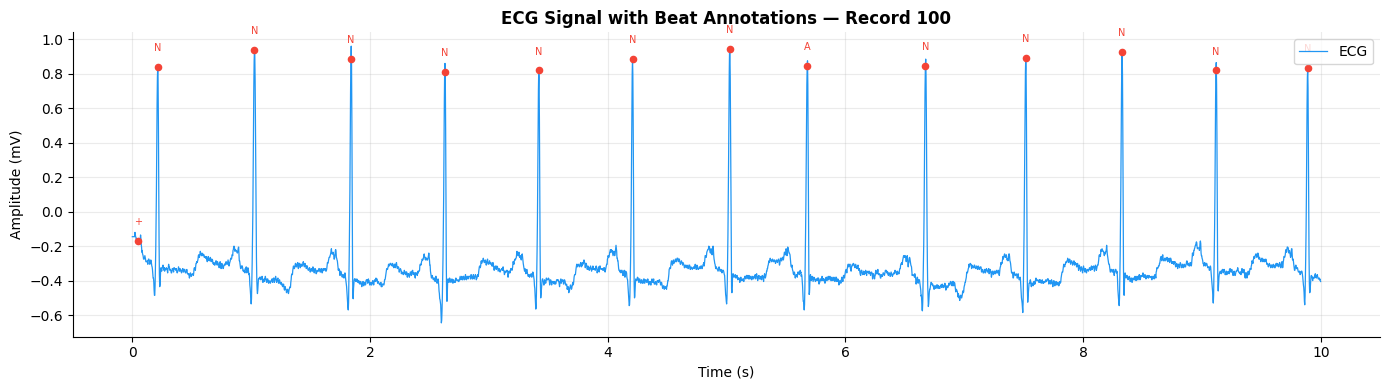

In [3]:
PREVIEW_RECORD = "100"
PREVIEW_DURATION = 10  # seconds

record     = wfdb.rdrecord(PREVIEW_RECORD, pn_dir="mitdb")
annotation = wfdb.rdann(PREVIEW_RECORD, "atr", pn_dir="mitdb")

signal  = record.p_signal[:, 0]
fs      = record.fs
t       = np.arange(len(signal)) / fs
samples = int(PREVIEW_DURATION * fs)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(t[:samples], signal[:samples], color="#2196F3", linewidth=0.9, label="ECG")

for s, sym in zip(annotation.sample, annotation.symbol):
    if s < samples:
        ax.scatter(s / fs, signal[s], color="#F44336", s=20, zorder=3)
        ax.text(s / fs, signal[s] + 0.08, sym, fontsize=7, color="#F44336",
                ha="center", va="bottom")

ax.set_title(f"ECG Signal with Beat Annotations — Record {PREVIEW_RECORD}",
             fontweight="bold")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (mV)")
ax.grid(alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 2. Data Preparation & Labelling

Each record is filtered with a **0.5–40 Hz bandpass** to remove baseline wander and high-frequency noise. Beats are segmented around annotated R-peaks with a fixed window of **200 ms pre** and **400 ms post** the peak.

Raw MIT-BIH symbols are mapped to the 5-class AAMI grouping before saving.

In [4]:
# AAMI 5-class label map
LABEL_MAP = {
    "N": "N", "L": "N", "R": "N", "e": "N", "j": "N",    # Normal
    "A": "S", "a": "S", "J": "S", "S": "S",                # Supraventricular
    "V": "V", "E": "V",                                     # Ventricular
    "F": "F",                                               # Fusion
    "/": "Q", "f": "Q", "Q": "Q", "x": "Q", "X": "Q",     # Unknown / Paced
}

LABEL_FULL = {
    "N": "Normal", "S": "Supraventricular",
    "V": "Ventricular", "F": "Fusion", "Q": "Unknown / Paced"
}

CLASS_COLORS = {
    "N": "#2196F3", "S": "#4CAF50", "V": "#F44336",
    "F": "#FF9800", "Q": "#9C27B0"
}


def bandpass_filter(signal, fs, lowcut=0.5, highcut=40.0, order=4):
    """Butterworth bandpass filter to remove baseline wander and HF noise."""
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype="band")
    return filtfilt(b, a, signal)


def preprocess_ecg(record_path, window_pre=0.2, window_post=0.4):
    """Load, filter, and segment one MIT-BIH record into labelled beats."""
    try:
        rec = wfdb.rdrecord(record_path)
        ann = wfdb.rdann(record_path, "atr")
        sig = bandpass_filter(rec.p_signal[:, 0], rec.fs)
        wp, ws = int(window_pre * rec.fs), int(window_post * rec.fs)

        beats, labels = [], []
        for r, lbl in zip(ann.sample, ann.symbol):
            if r - wp >= 0 and r + ws < len(sig):
                beats.append(sig[r - wp : r + ws])
                labels.append(LABEL_MAP.get(lbl, "Q"))

        return np.array(beats, dtype=np.float32), np.array(labels)
    except Exception as e:
        print(f"  Error in {record_path}: {e}")
        return np.array([], dtype=np.float32), np.array([])


# Extract beats from all records
all_beats, all_labels = [], []

for rec in RECORD_IDS:
    beats, labels = preprocess_ecg(os.path.join(DATA_DIR, rec))
    if beats.size > 0:
        all_beats.append(beats)
        all_labels.append(labels)
        print(f"  {rec}: {len(beats):,} beats")

if not all_beats:
    raise RuntimeError("No beats extracted — check DATA_DIR and record files.")

all_beats  = np.vstack(all_beats)
all_labels = np.concatenate(all_labels)
print(f"\nTotal beats: {len(all_beats):,}")
print(f"Label distribution: {Counter(all_labels)}")


# Apply per-class cap
if MAX_PER_CLASS:
    rng = np.random.default_rng(42)
    indices_by_class = defaultdict(list)
    for i, lbl in enumerate(all_labels):
        indices_by_class[lbl].append(i)

    selected = []
    for cls, idxs in indices_by_class.items():
        n_keep = min(len(idxs), MAX_PER_CLASS.get(cls, len(idxs)))
        selected.extend(rng.choice(idxs, size=n_keep, replace=False))
        print(f"  {cls}: kept {n_keep:,} / {len(idxs):,}")

    selected     = np.array(selected)
    rng.shuffle(selected)
    final_beats  = all_beats[selected]
    final_labels = all_labels[selected]
else:
    final_beats, final_labels = all_beats, all_labels

print(f"\nFinal dataset: {len(final_beats):,} beats")
print(f"Final distribution: {Counter(final_labels)}")

np.save(OUT_BEATS,  final_beats)
np.save(OUT_LABELS, final_labels)
print(f"\nSaved -> {OUT_BEATS}, {OUT_LABELS}")

  100: 2,272 beats
  101: 1,873 beats
  102: 2,191 beats
  103: 2,089 beats
  104: 2,309 beats
  105: 2,690 beats
  107: 2,139 beats
  108: 1,823 beats
  109: 2,533 beats
  111: 2,132 beats
  112: 2,548 beats
  115: 1,960 beats
  116: 2,420 beats
  117: 1,538 beats
  118: 2,299 beats
  121: 1,874 beats
  122: 2,477 beats
  123: 1,517 beats
  124: 1,633 beats
  200: 2,790 beats
  201: 2,038 beats
  202: 2,145 beats
  203: 3,106 beats
  205: 2,670 beats
  207: 2,383 beats
  Error in data/raw/mitdb\208: [Errno 2] No such file or directory: 'd:/Project Repos/ECG-Classifier/data/raw/mitdb/208.dat'
  209: 3,051 beats
  210: 2,682 beats
  212: 2,762 beats
  213: 3,292 beats
  214: 2,294 beats
  Error in data/raw/mitdb\215: [Errno 2] No such file or directory: 'd:/Project Repos/ECG-Classifier/data/raw/mitdb/215.dat'
  Error in data/raw/mitdb\217: [Errno 2] No such file or directory: 'd:/Project Repos/ECG-Classifier/data/raw/mitdb/217.hea'
  Error in data/raw/mitdb\219: [Errno 2] No such file o

### 2.1 Preprocessing Visualization

The plots below show raw ECG data, the bandpass-filtered signal, and the final beat segment used for modelling. This lets you inspect the full preprocessing pipeline step by step for one representative R-peak.

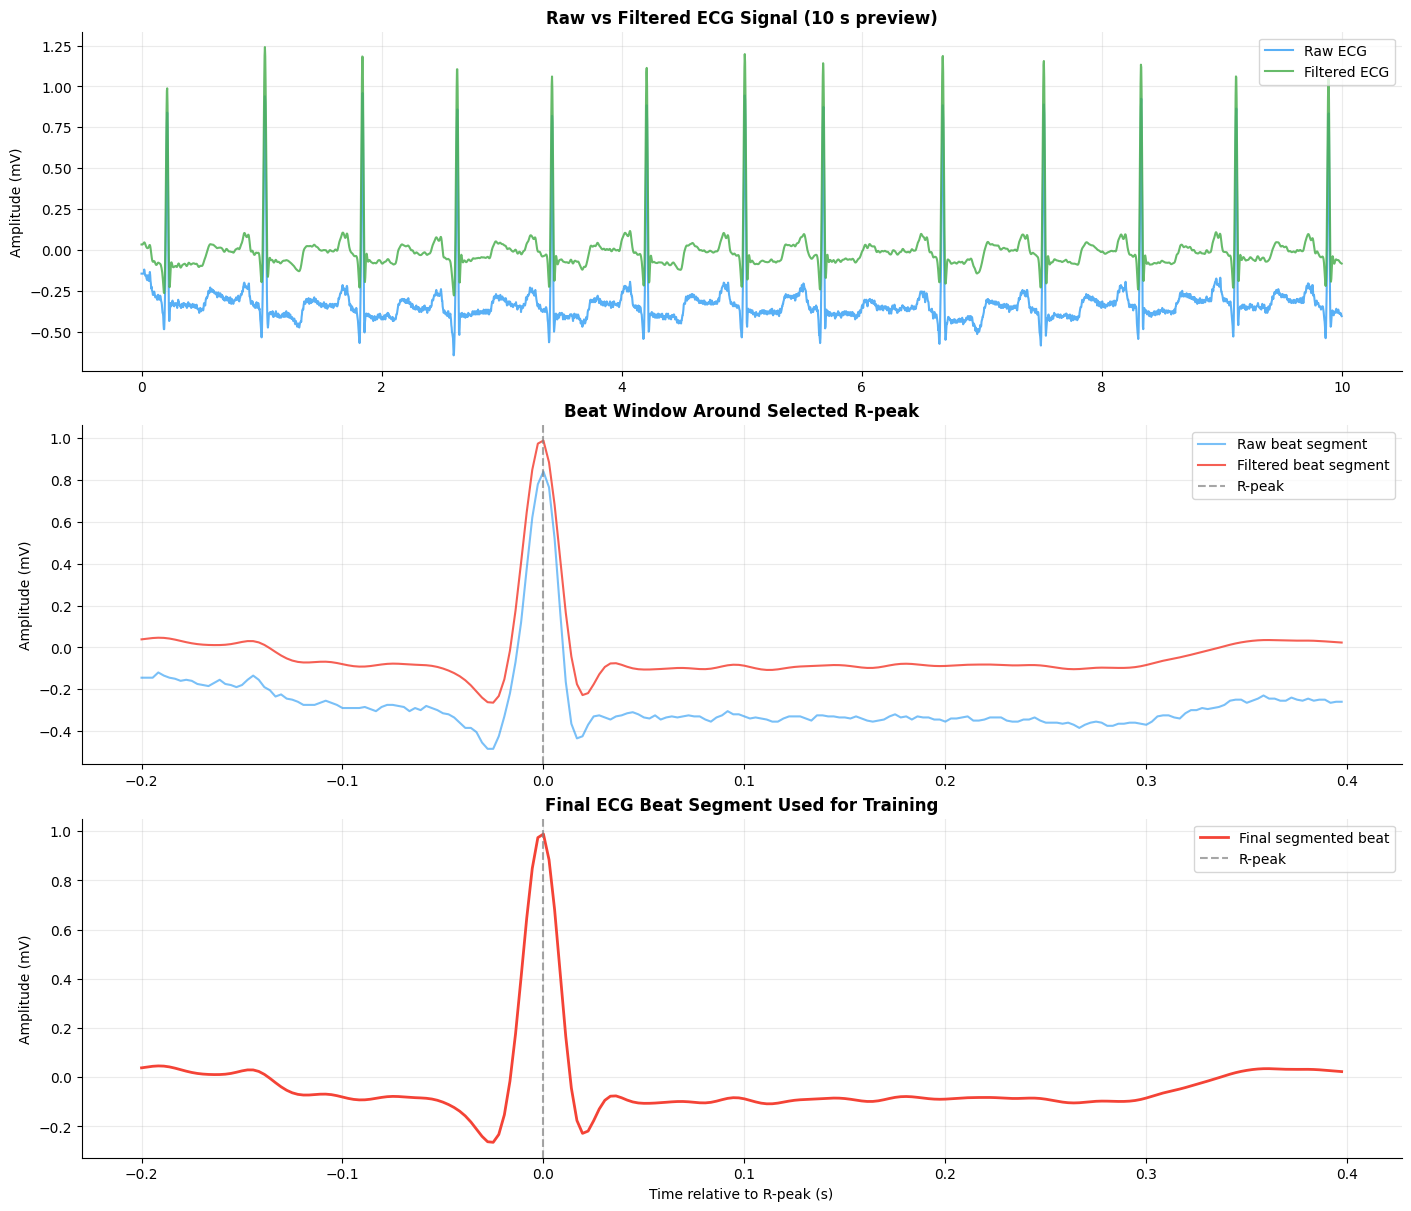

In [5]:
# Visualize raw → filtered → segmented ECG for one representative beat
record          = wfdb.rdrecord(PREVIEW_RECORD, pn_dir="mitdb")
ann             = wfdb.rdann(PREVIEW_RECORD, "atr", pn_dir="mitdb")
raw_signal      = record.p_signal[:, 0]
filtered_signal = bandpass_filter(raw_signal, record.fs)

window_pre  = int(0.2 * record.fs)
window_post = int(0.4 * record.fs)
samples     = int(PREVIEW_DURATION * record.fs)

valid_beats = [s for s in ann.sample if s >= window_pre and s + window_post < len(filtered_signal)]
beat_center = valid_beats[0] if valid_beats else ann.sample[0]

beat_start = beat_center - window_pre
beat_end   = beat_center + window_post

t_full    = np.arange(samples) / record.fs
t_segment = np.arange(len(filtered_signal[beat_start:beat_end])) / record.fs - 0.2

fig, axs = plt.subplots(3, 1, figsize=(14, 12), constrained_layout=True)

axs[0].plot(t_full, raw_signal[:samples], label="Raw ECG", color="#2196F3", alpha=0.75)
axs[0].plot(t_full, filtered_signal[:samples], label="Filtered ECG", color="#4CAF50", alpha=0.85)
axs[0].set_title("Raw vs Filtered ECG Signal (10 s preview)", fontweight="bold")
axs[0].set_ylabel("Amplitude (mV)")
axs[0].grid(alpha=0.25)
axs[0].legend(loc="upper right")
axs[0].spines[["top", "right"]].set_visible(False)

axs[1].plot(t_segment, raw_signal[beat_start:beat_end], label="Raw beat segment", color="#2196F3", alpha=0.6)
axs[1].plot(t_segment, filtered_signal[beat_start:beat_end], label="Filtered beat segment", color="#F44336", alpha=0.85)
axs[1].axvline(0.0, color="grey", linestyle="--", alpha=0.7, label="R-peak")
axs[1].set_title("Beat Window Around Selected R-peak", fontweight="bold")
axs[1].set_ylabel("Amplitude (mV)")
axs[1].legend(loc="upper right")
axs[1].grid(alpha=0.25)
axs[1].spines[["top", "right"]].set_visible(False)

axs[2].plot(t_segment, filtered_signal[beat_start:beat_end], label="Final segmented beat", color="#F44336", linewidth=2)
axs[2].axvline(0.0, color="grey", linestyle="--", alpha=0.7, label="R-peak")
axs[2].set_title("Final ECG Beat Segment Used for Training", fontweight="bold")
axs[2].set_xlabel("Time relative to R-peak (s)")
axs[2].set_ylabel("Amplitude (mV)")
axs[2].legend(loc="upper right")
axs[2].grid(alpha=0.25)
axs[2].spines[["top", "right"]].set_visible(False)

plt.show()

### 2.2 Beat Sample Visualisation

One representative beat per class to verify segmentation quality and observe morphological differences. The dashed grey line marks the R-peak position.

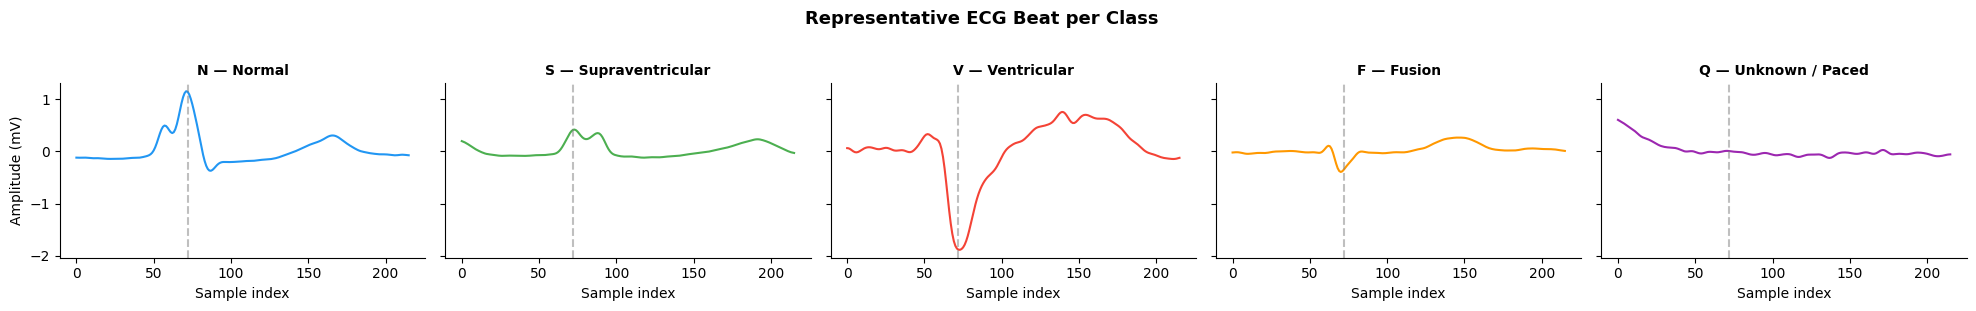

In [6]:
beats  = np.load(OUT_BEATS)
labels = np.load(OUT_LABELS)
classes = [c for c in ["N", "S", "V", "F", "Q"] if c in labels]

fig, axes = plt.subplots(1, len(classes), figsize=(4 * len(classes), 3), sharey=True)
if len(classes) == 1:
    axes = [axes]

for ax, cls in zip(axes, classes):
    beat   = beats[np.where(labels == cls)[0][0]]
    t      = np.arange(len(beat))
    r_peak = int(len(beat) * 0.2 / 0.6)

    ax.plot(t, beat, color=CLASS_COLORS[cls], linewidth=1.5)
    ax.axvline(r_peak, color="grey", linestyle="--", alpha=0.5, label="R-peak")
    ax.set_title(f"{cls} — {LABEL_FULL[cls]}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Sample index")
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Amplitude (mV)")
fig.suptitle("Representative ECG Beat per Class", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 3. CNN Model Definition & Training

Architecture: three `Conv1D -> BatchNorm -> Pooling` blocks followed by `GlobalAveragePooling1D` and a `Dense` head with dropout.

| Block | Filters | Kernel | Pooling |
|-------|---------|--------|---------|
| 1 | 32 | 7 | MaxPool(2) |
| 2 | 64 | 5 | MaxPool(2) |
| 3 | 128 | 3 | GlobalAvgPool |

Training uses **class weighting**, **early stopping** (patience = 5), and a **model checkpoint** to keep the best validation-loss epoch.

In [7]:
# Load & encode
X = np.load(OUT_BEATS)[..., np.newaxis]   # (N, seq_len, 1)
y = np.load(OUT_LABELS)

# Drop classes with fewer than MIN_SAMPLES samples, then re-encode
MIN_SAMPLES  = 5
keep_labels  = [lbl for lbl, n in Counter(y).items() if n >= MIN_SAMPLES]
keep         = np.isin(y, keep_labels)
X, y         = X[keep], y[keep]

encoder     = LabelEncoder()
y_enc       = encoder.fit_transform(y)
num_classes = len(encoder.classes_)

np.save("data/processed/label_classes.npy", encoder.classes_)
print(f"Classes ({num_classes}): {encoder.classes_}")
print(f"Total samples: {len(X):,}")

# Train / val / test split (80 / 10 / 10)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_enc, test_size=0.20, stratify=y_enc, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)
print(f"Split -- Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")

y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes)
y_val_cat   = tf.keras.utils.to_categorical(y_val,   num_classes)

cw_dict = dict(enumerate(
    compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
))


def build_cnn(input_shape, num_classes):
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),

        tf.keras.layers.Conv1D(32,  7, padding="same", activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(2),

        tf.keras.layers.Conv1D(64,  5, padding="same", activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(2),

        tf.keras.layers.Conv1D(128, 3, padding="same", activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.GlobalAveragePooling1D(),

        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ], name="ECG_CNN")


model = build_cnn(X_train.shape[1:], num_classes)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "models/cnn_ecg_best.keras", save_best_only=True
    ),
]

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=30,
    batch_size=64,
    class_weight=cw_dict,
    callbacks=callbacks,
    verbose=1,
)

model.save("models/cnn_ecg_final.keras")
print("Saved -> models/cnn_ecg_final.keras")

Classes (5): ['F' 'N' 'Q' 'S' 'V']
Total samples: 21,831
Split -- Train: 17,464  Val: 2,183  Test: 2,184


Model: "ECG_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 216, 32)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 216, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 108, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 108, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 108, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 54, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 54, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 54, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,317 (208.27 KB)

 Trainable params: 52,869 (206.52 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.6330 - loss: 0.8350 - val_accuracy: 0.1278 - val_loss: 1.7053
Epoch 2/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.7552 - loss: 0.6135 - val_accuracy: 0.7174 - val_loss: 0.8231
Epoch 3/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.7959 - loss: 0.5344 - val_accuracy: 0.8085 - val_loss: 0.5453
Epoch 4/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.8144 - loss: 0.4756 - val_accuracy: 0.6106 - val_loss: 0.9436
Epoch 5/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.8380 - loss: 0.4282 - val_accuracy: 0.8328 - val_loss: 0.4690
Epoch 6/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8540 - loss: 0.3931 - val_accuracy: 0.8598 - val_loss: 0.3989
Epoch 7/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.8607 - loss: 0.3621 - val_accuracy: 0.7820 - val_loss: 0.5372
Epoch 8/30
273/273 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.8732 - loss: 0.3337 - val_acc

### 3.1 Training Curves

Loss and accuracy over epochs. The dashed line marks the best epoch chosen by early stopping.

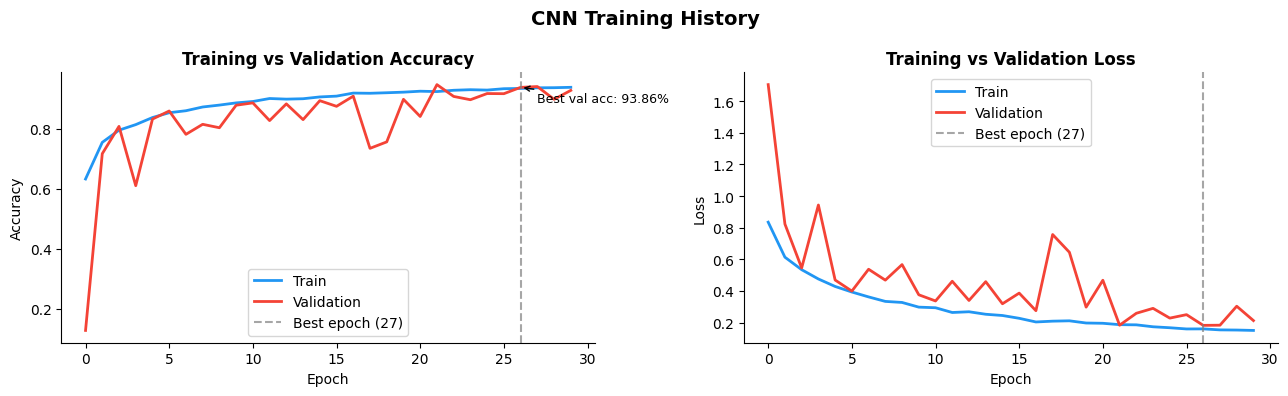

In [8]:
best_epoch    = int(np.argmin(history.history["val_loss"]))
final_val_acc = history.history["val_accuracy"][best_epoch]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

for ax, metric, title in [(ax1, "accuracy", "Accuracy"), (ax2, "loss", "Loss")]:
    ax.plot(history.history[metric],          label="Train",      color="#2196F3", linewidth=2)
    ax.plot(history.history[f"val_{metric}"], label="Validation", color="#F44336", linewidth=2)
    ax.axvline(best_epoch, color="grey", linestyle="--", alpha=0.7,
               label=f"Best epoch ({best_epoch + 1})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.set_title(f"Training vs Validation {title}", fontweight="bold")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)

ax1.annotate(
    f"Best val acc: {final_val_acc:.2%}",
    xy=(best_epoch, final_val_acc),
    xytext=(best_epoch + 1, final_val_acc - 0.05),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=9,
)

fig.suptitle("CNN Training History", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Model Evaluation

The best checkpoint is evaluated on the held-out test set. Metrics: **precision**, **recall**, **F1-score** per class, plus annotated confusion matrices (raw counts and row-normalised recall).

In [9]:
best_model = tf.keras.models.load_model("models/cnn_ecg_best.keras", compile=False)

y_pred_probs         = best_model.predict(X_test, verbose=0)
y_pred               = np.argmax(y_pred_probs, axis=1)
y_true               = y_test
labels_present       = np.unique(y_true)
target_names_present = encoder.classes_[labels_present]
overall_acc          = np.mean(y_true == y_pred)

print("Classification Report\n" + "=" * 50)
print(classification_report(
    y_true, y_pred,
    labels=labels_present,
    target_names=target_names_present,
    digits=4,
))
print(f"Overall Test Accuracy: {overall_acc:.4f}")

Classification Report
              precision    recall  f1-score   support

           F     0.7333    0.8250    0.7765        40
           N     0.9679    0.9360    0.9517      1000
           Q     0.9725    0.9599    0.9661       773
           S     0.6748    0.8925    0.7685        93
           V     0.9266    0.9532    0.9397       278

    accuracy                         0.9428      2184
   macro avg     0.8550    0.9133    0.8805      2184
weighted avg     0.9475    0.9428    0.9443      2184

Overall Test Accuracy: 0.9428


### 4.1 Confusion Matrix

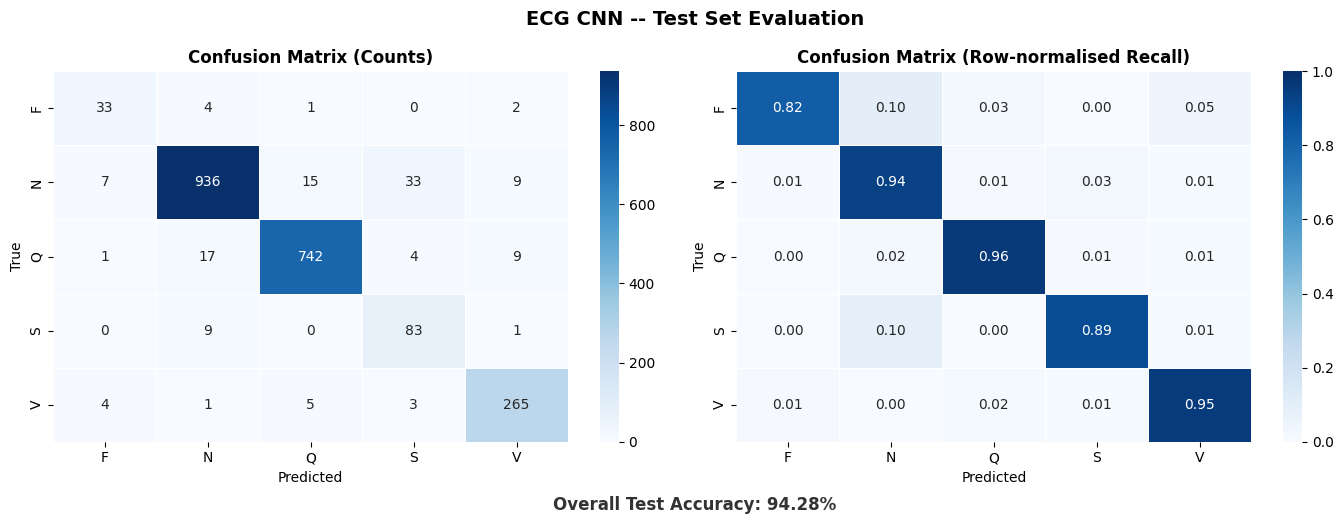

In [10]:
cm      = confusion_matrix(y_true, y_pred, labels=labels_present)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, (ax_raw, ax_norm) = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, fmt, title in [
    (ax_raw,  cm,      "d",   "Counts"),
    (ax_norm, cm_norm, ".2f", "Row-normalised Recall"),
]:
    sns.heatmap(
        data, annot=True, fmt=fmt, cmap="Blues",
        xticklabels=target_names_present, yticklabels=target_names_present,
        ax=ax, linewidths=0.5,
        vmin=(0 if fmt == ".2f" else None),
        vmax=(1 if fmt == ".2f" else None),
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"Confusion Matrix ({title})", fontweight="bold")

fig.text(
    0.5, -0.02, f"Overall Test Accuracy: {overall_acc:.2%}",
    ha="center", fontsize=12, fontweight="bold", color="#333"
)
plt.suptitle("ECG CNN -- Test Set Evaluation", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 4.2 Per-Class Confidence Distribution

Softmax probability assigned to the **true class** for each test sample. A high median and tight spread indicates the model is reliably confident when it is correct.

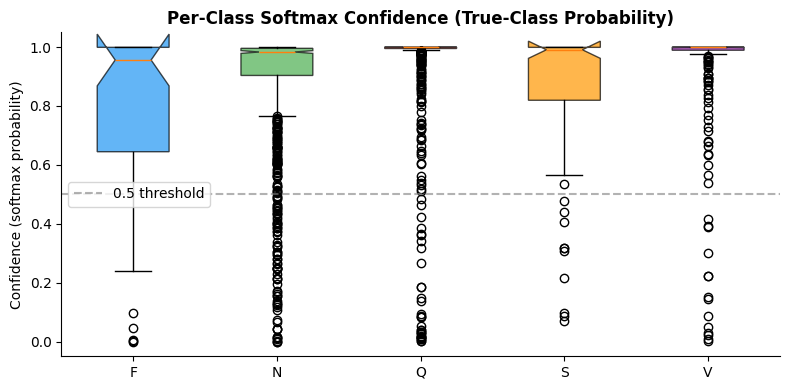

In [11]:
conf_per_class = [y_pred_probs[y_true == lbl, lbl] for lbl in labels_present]
palette        = ["#2196F3", "#4CAF50", "#F44336", "#FF9800", "#9C27B0"]

fig, ax = plt.subplots(figsize=(8, 4))

bp = ax.boxplot(conf_per_class, patch_artist=True, notch=True)
for patch, col in zip(bp["boxes"], palette):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)

ax.set_xticks(range(1, len(target_names_present) + 1))
ax.set_xticklabels(target_names_present)
ax.set_ylabel("Confidence (softmax probability)")
ax.set_title("Per-Class Softmax Confidence (True-Class Probability)", fontweight="bold")
ax.axhline(0.5, color="grey", linestyle="--", alpha=0.6, label="0.5 threshold")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## 5. Grad-CAM Explainability

**Grad-CAM** computes the gradient of the target class score with respect to the last `Conv1D` layer, then pools over channels to produce a 1-D importance heatmap aligned to the input signal. Red regions indicate where the model focuses most.

`grad_cam_1d` automatically resolves the last Conv1D layer when `layer_name=None`, so it works without knowing the exact layer name.

In [12]:
def grad_cam_1d(model, signal, class_index=None, layer_name=None):
    """
    Compute a Grad-CAM heatmap for a 1-D CNN.

    Parameters
    ----------
    model       : trained tf.keras model
    signal      : array of shape (seq_len,) or (seq_len, 1)
    class_index : target class index; defaults to argmax of predictions
    layer_name  : Conv1D layer to explain; defaults to last Conv1D in model

    Returns
    -------
    heatmap : 1-D array normalised to [0, 1], length = seq_len
    """
    signal = np.asarray(signal, dtype=np.float32)
    if signal.ndim == 1:
        signal = signal[:, np.newaxis]
    inp = signal[np.newaxis]

    # Auto-resolve last Conv1D layer
    if layer_name is None:
        for layer in reversed(model.layers):
            if isinstance(layer, tf.keras.layers.Conv1D):
                layer_name = layer.name
                break
    if layer_name is None:
        raise ValueError("No Conv1D layer found in model.")

    target_layer = model.get_layer(layer_name)

    # Split model at target layer
    conv_model = tf.keras.Model(inputs=model.inputs, outputs=target_layer.output)

    classifier_input = tf.keras.Input(shape=target_layer.output.shape[1:])
    x = classifier_input
    past_target = False
    for layer in model.layers:
        if layer.name == layer_name:
            past_target = True
            continue
        if past_target:
            x = layer(x, training=False)
    classifier_model = tf.keras.Model(classifier_input, x)

    inp_tf = tf.convert_to_tensor(inp, dtype=tf.float32)

    with tf.GradientTape() as tape:
        conv_out = conv_model(inp_tf, training=False)
        tape.watch(conv_out)
        preds = classifier_model(conv_out, training=False)
        if class_index is None:
            class_index = int(tf.argmax(preds[0]))
        loss = preds[:, class_index]

    grads = tape.gradient(loss, conv_out)
    if grads is None:
        raise ValueError(f"Gradient is None for layer '{layer_name}'.")

    weights  = tf.reduce_mean(grads, axis=1)                        # (1, C)
    cam      = tf.reduce_sum(conv_out[0] * weights[0], axis=-1)     # (T',)
    heatmap  = tf.nn.relu(cam).numpy()
    if heatmap.max() > 0:
        heatmap /= heatmap.max()

    # Upsample to input length
    return np.interp(
        np.linspace(0, 1, signal.shape[0]),
        np.linspace(0, 1, len(heatmap)),
        heatmap,
    )


def plot_gradcam_ecg(signal, heatmap, title="Grad-CAM on ECG Beat"):
    """Two-panel plot: colour-coded ECG waveform + importance bar."""
    signal = np.squeeze(signal)
    t      = np.arange(len(signal))
    norm   = Normalize(vmin=0, vmax=1)

    fig, axes = plt.subplots(
        2, 1, figsize=(13, 5), sharex=True,
        gridspec_kw={"height_ratios": [3, 1]}
    )

    # Top: ECG coloured by heatmap intensity
    points   = np.array([t, signal]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap="jet", norm=norm, linewidth=2)
    lc.set_array(heatmap[:-1])
    axes[0].add_collection(lc)
    axes[0].set_xlim(t[0], t[-1])
    axes[0].set_ylim(signal.min() - 0.05, signal.max() + 0.05)
    axes[0].set_ylabel("Amplitude (mV)", fontsize=10)
    axes[0].set_title(title, fontsize=12, fontweight="bold")
    axes[0].spines[["top", "right"]].set_visible(False)

    peak_t = int(np.argmax(heatmap))
    axes[0].annotate(
        "Peak attention",
        xy=(peak_t, signal[peak_t]),
        xytext=(peak_t + 10, signal[peak_t] + 0.1),
        arrowprops=dict(arrowstyle="->", color="red"),
        color="red", fontsize=9,
    )

    sm = plt.cm.ScalarMappable(cmap="jet", norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=axes[0], label="Grad-CAM score", shrink=0.8)

    # Bottom: importance bar
    axes[1].imshow(
        heatmap[np.newaxis, :], aspect="auto",
        cmap="jet", extent=[0, len(signal), 0, 1],
    )
    axes[1].set_yticks([])
    axes[1].set_xlabel("Sample index", fontsize=10)
    axes[1].set_title("Grad-CAM Importance Map", fontsize=10)

    plt.tight_layout()
    plt.show()

### 5.1 Grad-CAM — Single Beat

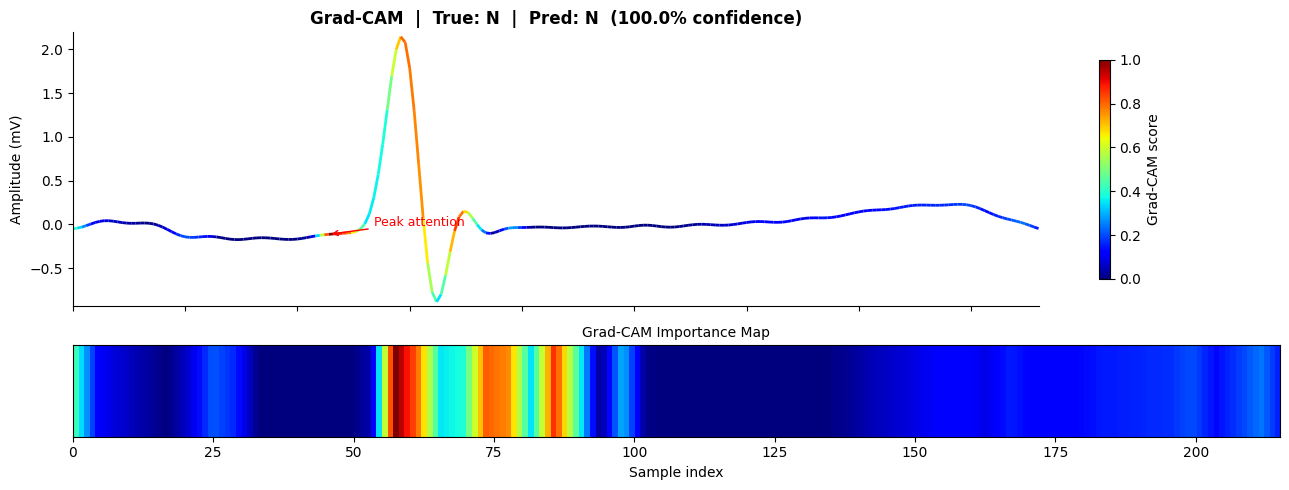

In [13]:
sample_idx   = 0
sample_sig   = X_test[sample_idx]
pred_probs_s = best_model.predict(sample_sig[np.newaxis], verbose=0)
pred_class   = int(np.argmax(pred_probs_s[0]))
true_class   = int(y_test[sample_idx])
conf         = pred_probs_s[0][pred_class]

heatmap = grad_cam_1d(
    best_model,
    sample_sig,
    class_index=pred_class,
    layer_name=None  # auto-select
)

plot_gradcam_ecg(
    sample_sig, heatmap,
    title=(
        f"Grad-CAM  |  "
        f"True: {encoder.classes_[true_class]}  |  "
        f"Pred: {encoder.classes_[pred_class]}  ({conf:.1%} confidence)"
    )
)

### 5.2 Grad-CAM Grid — One Correctly Classified Beat per Class

Compares which waveform regions the model attends to across arrhythmia types.

C:\Users\User\AppData\Local\Temp\ipykernel_21808\3666067976.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


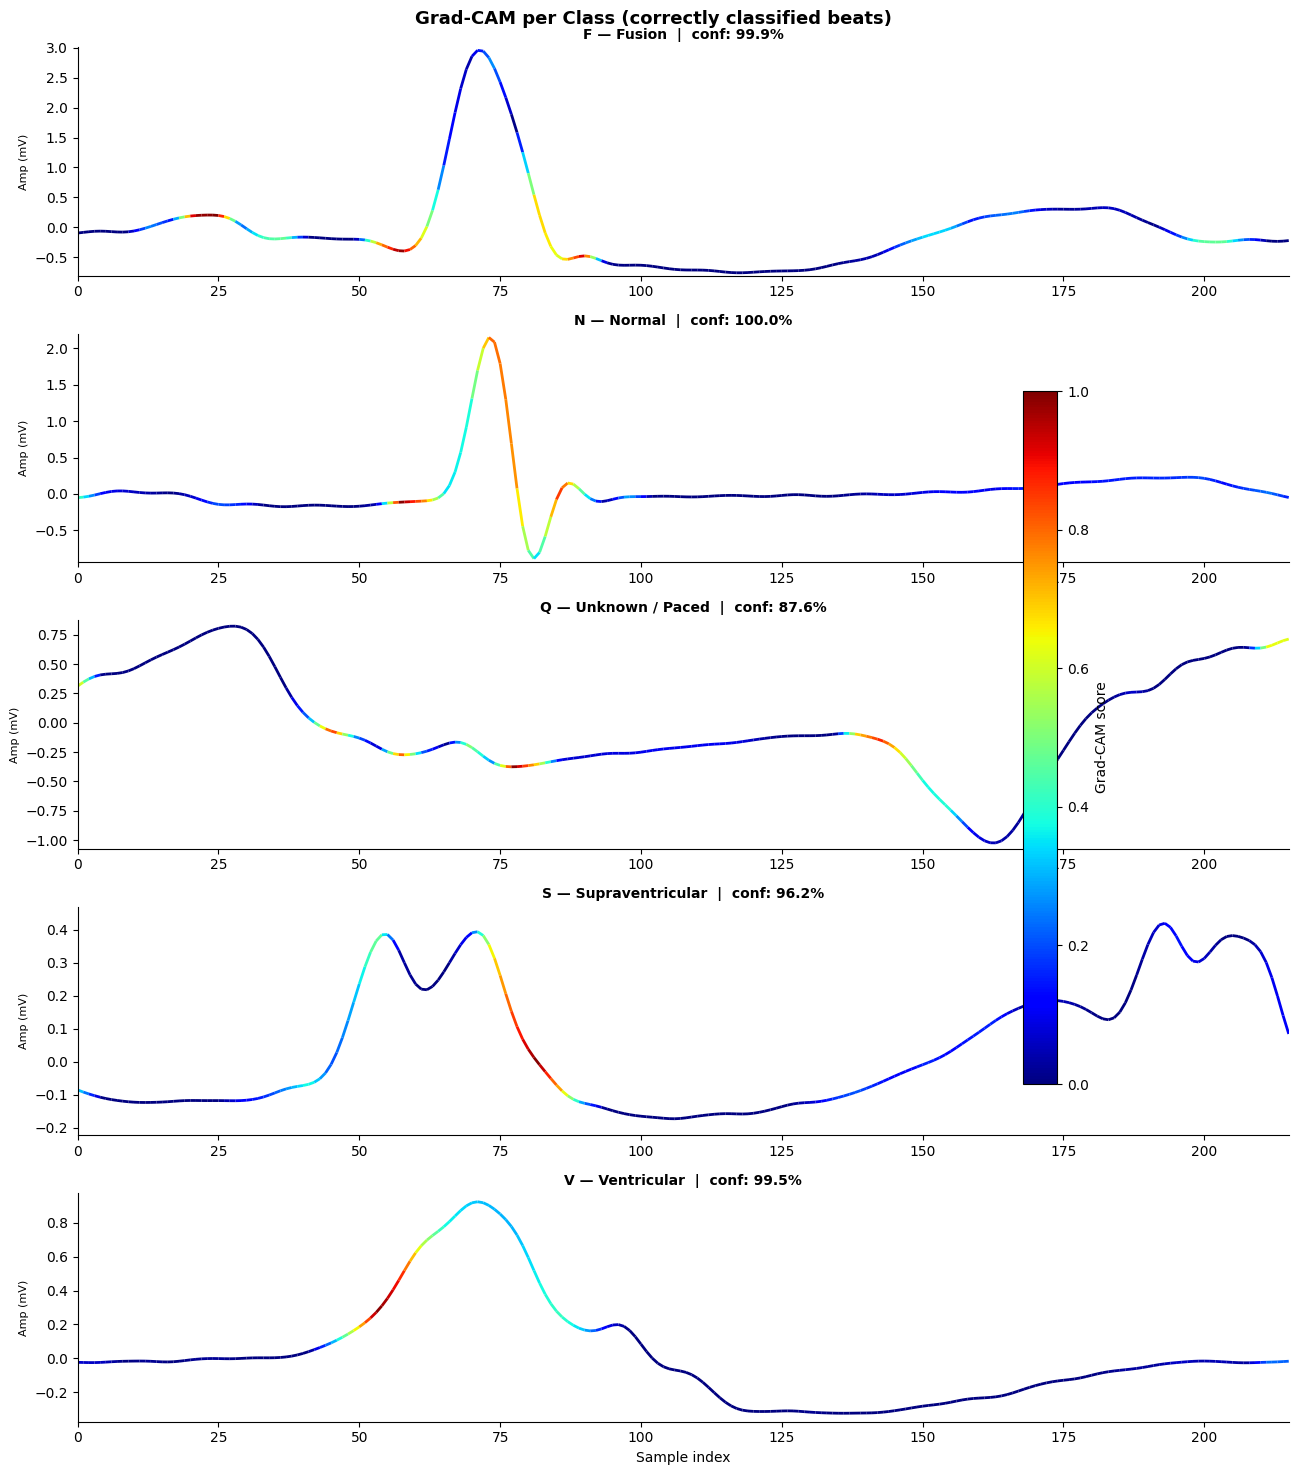

In [14]:
fig, axes = plt.subplots(
    len(labels_present), 1,
    figsize=(13, 3 * len(labels_present)),
    sharex=False,
)
if len(labels_present) == 1:
    axes = [axes]

norm = Normalize(vmin=0, vmax=1)

for ax, lbl in zip(axes, labels_present):
    candidates = np.where((y_true == lbl) & (y_pred == lbl))[0]
    if len(candidates) == 0:
        ax.set_visible(False)
        continue

    sig  = np.squeeze(X_test[candidates[0]])
    conf = y_pred_probs[candidates[0], lbl]
    hm   = grad_cam_1d(best_model, sig, class_index=int(lbl))
    t    = np.arange(len(sig))

    points   = np.array([t, sig]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap="jet", norm=norm, linewidth=2)
    lc.set_array(hm[:-1])
    ax.add_collection(lc)
    ax.set_xlim(t[0], t[-1])
    ax.set_ylim(sig.min() - 0.05, sig.max() + 0.05)

    cls_name = encoder.classes_[lbl]
    ax.set_title(
        f"{cls_name} — {LABEL_FULL.get(cls_name, '')}  |  conf: {conf:.1%}",
        fontsize=10, fontweight="bold"
    )
    ax.set_ylabel("Amp (mV)", fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

# Shared colorbar on the right
sm = plt.cm.ScalarMappable(cmap="jet", norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=axes, label="Grad-CAM score", shrink=0.6, pad=0.02)

axes[-1].set_xlabel("Sample index")
fig.suptitle(
    "Grad-CAM per Class (correctly classified beats)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

### 5.3 Mean Grad-CAM per Class

Averages Grad-CAM heatmaps over up to 50 correctly classified beats per class to reveal **consistent attention patterns** rather than individual sample quirks.

  F: averaged 33 beats
  N: averaged 50 beats
  Q: averaged 50 beats
  S: averaged 50 beats
  V: averaged 50 beats


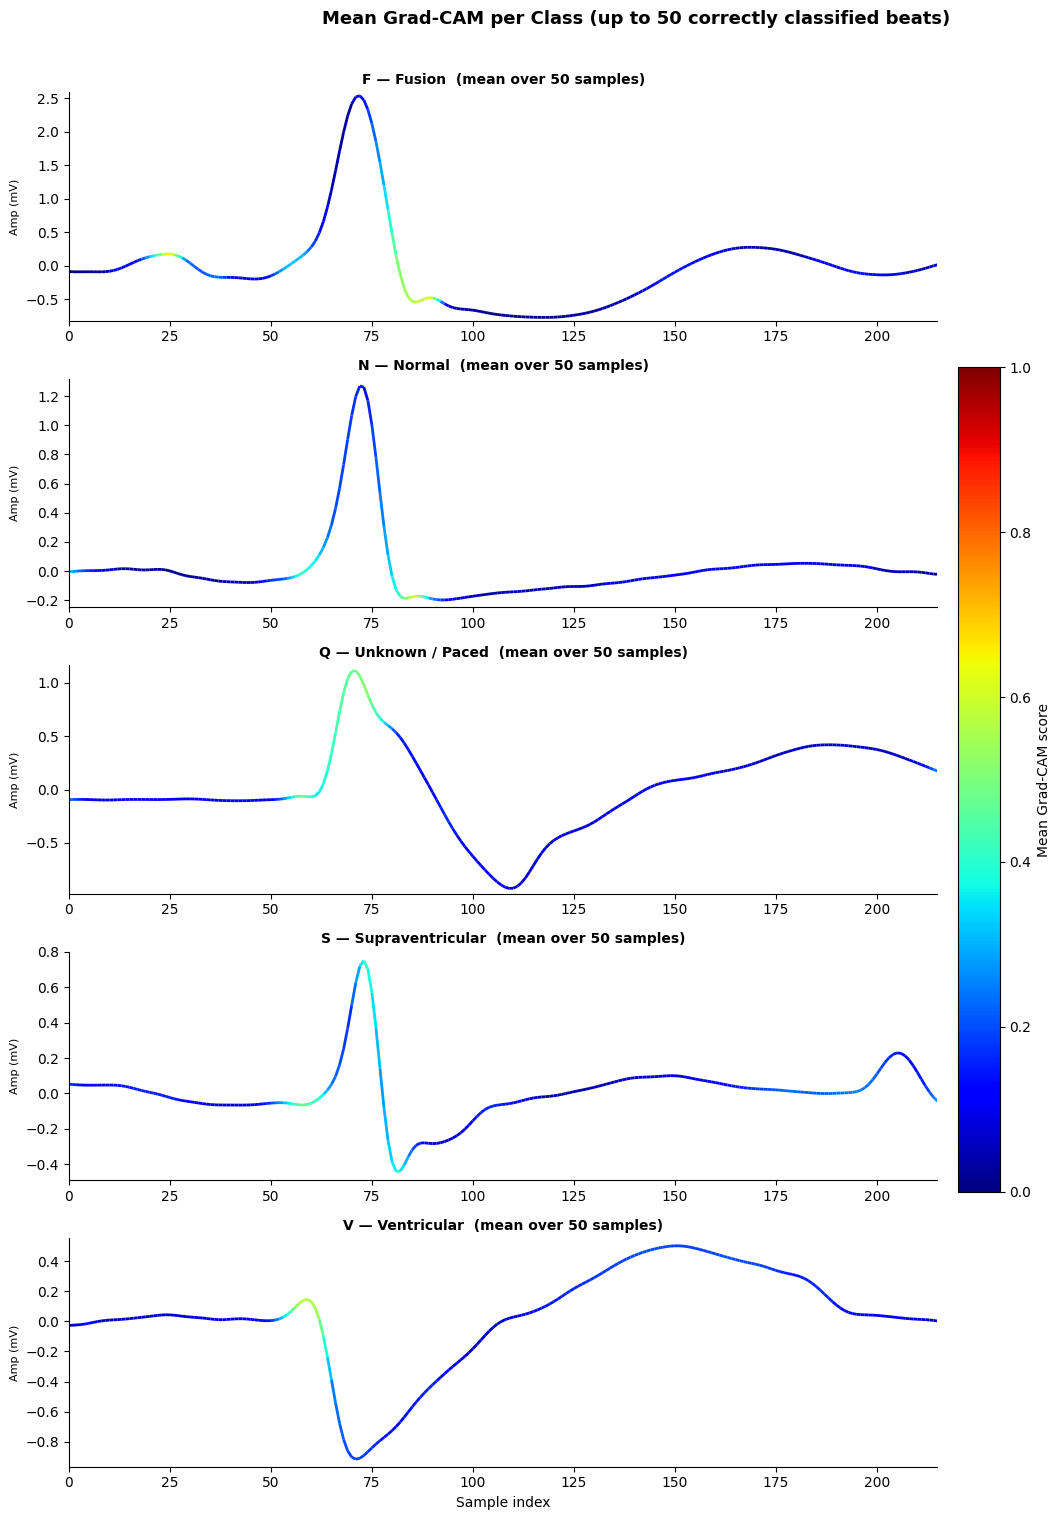

In [15]:
MAX_SAMPLES = 50

class_maps, class_signals = {}, {}

for cls in np.unique(y_true):
    idx = np.where((y_true == cls) & (y_pred == cls))[0][:MAX_SAMPLES]
    if len(idx) == 0:
        continue

    heatmaps, signals = [], []
    for i in idx:
        sig = np.squeeze(X_test[i])
        try:
            heatmaps.append(grad_cam_1d(best_model, sig, class_index=int(cls)))
            signals.append(sig)
        except Exception:
            continue

    if heatmaps:
        class_maps[cls]    = np.mean(heatmaps, axis=0)
        class_signals[cls] = np.mean(signals,  axis=0)
        print(f"  {encoder.classes_[cls]}: averaged {len(heatmaps)} beats")


# Plot
n    = len(class_maps)
norm = Normalize(vmin=0, vmax=1)

fig, axes = plt.subplots(n, 1, figsize=(13, 3 * n), sharex=False)
if n == 1:
    axes = [axes]

for ax, cls in zip(axes, sorted(class_maps.keys())):
    sig = class_signals[cls]
    hm  = class_maps[cls]
    t   = np.arange(len(sig))

    points   = np.array([t, sig]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap="jet", norm=norm, linewidth=2)
    lc.set_array(hm[:-1])
    ax.add_collection(lc)
    ax.set_xlim(t[0], t[-1])
    ax.set_ylim(sig.min() - 0.05, sig.max() + 0.05)

    cls_name = encoder.classes_[cls]
    ax.set_title(
        f"{cls_name} — {LABEL_FULL.get(cls_name, '')}  (mean over {len(heatmaps)} samples)",
        fontsize=10, fontweight="bold"
    )
    ax.set_ylabel("Amp (mV)", fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("Sample index")
fig.suptitle(
    f"Mean Grad-CAM per Class (up to {MAX_SAMPLES} correctly classified beats)",
    fontsize=13, fontweight="bold", y=1.01
)

# tight_layout BEFORE colorbar to avoid the incompatibility warning
fig.tight_layout(rect=[0, 0, 0.88, 1])

# Shared colorbar placed in the reserved right margin
sm = plt.cm.ScalarMappable(cmap="jet", norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=axes, label="Mean Grad-CAM score", shrink=0.6, pad=0.02)

plt.show()

### 5.4 Advanced Explainability: SHAP Feature Attribution

While Grad-CAM provides a spatial heatmap, SHAP calculates the exact numerical contribution of each time point. This helps in understanding if specific peaks (like the P-wave) or intervals (like the QRS duration) were the primary drivers for a specific classification.

Predicted class index: 1 → N
Attribution vector shape: (216,)


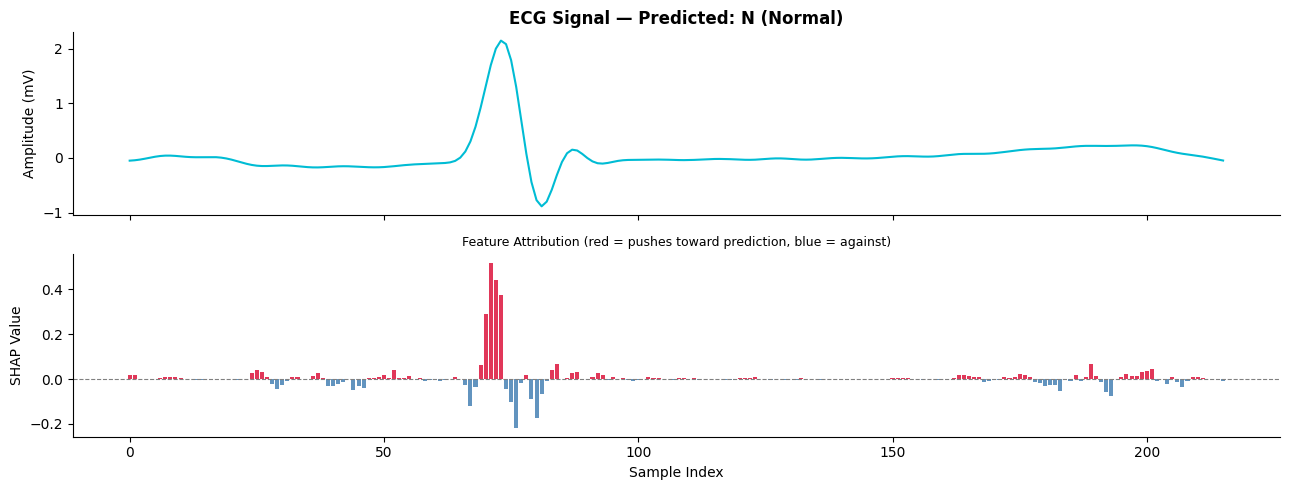

In [23]:
def explain_with_shap(model, input_signal):
    background  = np.zeros((1, 216, 1))
    explainer   = sh.GradientExplainer(model, background)
    shap_values = explainer.shap_values(input_signal)
    return shap_values


# --- Run SHAP on a single test sample ---
sample_idx  = 0
input_signal = X_test[sample_idx:sample_idx + 1]  # (1, 216, 1)

pred_probs = best_model.predict(input_signal, verbose=0)
pred_idx   = np.argmax(pred_probs)
print(f"Predicted class index: {pred_idx} → {encoder.classes_[pred_idx]}")

shap_values = explain_with_shap(best_model, input_signal)
# shap_values.shape → (1, 216, 1, 5)  i.e. (batch, timesteps, channels, n_classes)

sv = shap_values[0, :, 0, pred_idx]   # shape: (216,)
print(f"Attribution vector shape: {sv.shape}")

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)

# Top: raw signal
axes[0].plot(input_signal[0, :, 0], color='#00bcd4', linewidth=1.5)
axes[0].set_ylabel("Amplitude (mV)")
axes[0].set_title(
    f"ECG Signal — Predicted: {encoder.classes_[pred_idx]} "
    f"({LABEL_FULL.get(encoder.classes_[pred_idx], '')})",
    fontweight="bold"
)
axes[0].spines[["top", "right"]].set_visible(False)

# Bottom: SHAP attribution
colors = ['crimson' if v >= 0 else 'steelblue' for v in sv]
axes[1].bar(np.arange(len(sv)), sv, color=colors, alpha=0.85)
axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[1].set_ylabel("SHAP Value")
axes[1].set_xlabel("Sample Index")
axes[1].set_title(
    "Feature Attribution (red = pushes toward prediction, blue = against)",
    fontsize=9
)
axes[1].spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()